In [158]:
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import random
import os

In [159]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [160]:
df = pd.read_csv("S12-hw-dataset.csv")

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df.head()

,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62


In [161]:
print("Размер:", df.shape)
print("Диапазон дат:", df['date'].min(), "—", df['date'].max())

print("\nПропуски:")
print(df.isna().sum())

Размер: (4320, 2)
Диапазон дат: 2025-01-01 00:00:00 — 2025-06-29 23:00:00

Пропуски:
date      0
target    0
dtype: int64


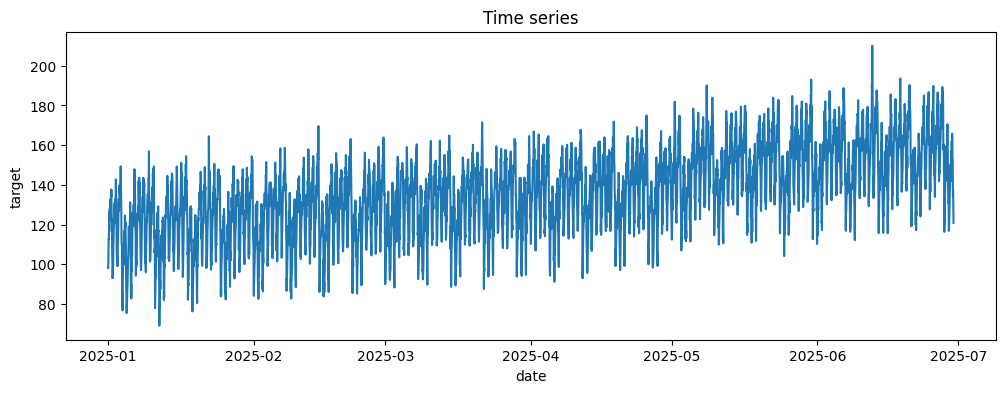

In [162]:
plt.figure(figsize=(12, 4))
plt.plot(df['date'], df['target'])
plt.title("Time series")
plt.xlabel("date")
plt.ylabel("target")
plt.show()

Тренд восходящий, видно четкое увеличение traget со временем. Четкой сезонности не наблюдается, на протяжении всего года target растет. Однако видно, что в пределах небольших периодов большие скачки данных.

In [163]:
n = len(df)

train_end = int(n * 0.7)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print(train_df['date'].min(), train_df['date'].max())
print(val_df['date'].min(), val_df['date'].max())
print(test_df['date'].min(), test_df['date'].max())

2025-01-01 00:00:00 2025-05-06 23:00:00
2025-05-07 00:00:00 2025-06-02 23:00:00
2025-06-03 00:00:00 2025-06-29 23:00:00


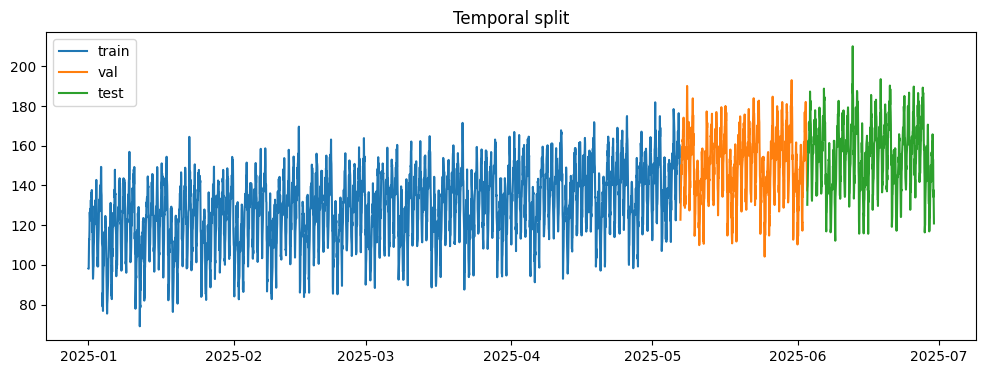

'\nПочему `random split` здесь некорректен\n\nRandom split некорректен для временных рядов, так как нарушает хронологический порядок данных. \nВ этом случае в обучающую выборку могут попасть наблюдения из будущего относительно validation/test, \nчто приводит к утечке информации (data leakage) и завышенной оценке качества модели.\n'

In [164]:
plt.figure(figsize=(12, 4))

plt.plot(train_df['date'], train_df['target'], label='train')
plt.plot(val_df['date'], val_df['target'], label='val')
plt.plot(test_df['date'], test_df['target'], label='test')

plt.legend()
plt.title("Temporal split")
plt.show()

"""
Почему `random split` здесь некорректен

Random split некорректен для временных рядов, так как нарушает хронологический порядок данных. 
В этом случае в обучающую выборку могут попасть наблюдения из будущего относительно validation/test, 
что приводит к утечке информации (data leakage) и завышенной оценке качества модели.
"""

Почему `random split` здесь некорректен

Random split некорректен для временных рядов, так как нарушает хронологический порядок данных. 
В этом случае в обучающую выборку могут попасть наблюдения из будущего относительно validation/test, 
что приводит к утечке информации (data leakage) и завышенной оценке качества модели.

Возможные утечки данных (`data leakage`)

В данной работе утечки избегаются следующим образом: все лаговые и rolling-признаки рассчитываются только на основе прошлых значений (через shift), а масштабирование (scaler) обучается только на тренировочной выборке и затем применяется к validation и test.

In [165]:
train_df['lag_1'] = train_df['target'].shift(1)
train_df['lag_7'] = train_df['target'].shift(7)
train_df['lag_14'] = train_df['target'].shift(14)
train_df['rolling_mean_7'] = train_df['target'].shift(1).rolling(7).mean()
train_df['rolling_std_7'] = train_df['target'].shift(1).rolling(7).std()
train_df['day_of_week'] = train_df['date'].dt.dayofweek
train_df = train_df.dropna().reset_index(drop=True)

val_df['lag_1'] = val_df['target'].shift(1)
val_df['lag_7'] = val_df['target'].shift(7)
val_df['lag_14'] = val_df['target'].shift(14)
val_df['rolling_mean_7'] = val_df['target'].shift(1).rolling(7).mean()
val_df['rolling_std_7'] = val_df['target'].shift(1).rolling(7).std()
val_df['day_of_week'] = val_df['date'].dt.dayofweek
val_df = val_df.dropna().reset_index(drop=True)

test_df['lag_1'] = test_df['target'].shift(1)
test_df['lag_7'] = test_df['target'].shift(7)
test_df['lag_14'] = test_df['target'].shift(14)
test_df['rolling_mean_7'] = test_df['target'].shift(1).rolling(7).mean()
test_df['rolling_std_7'] = test_df['target'].shift(1).rolling(7).std()
test_df['day_of_week'] = test_df['date'].dt.dayofweek
test_df = test_df.dropna().reset_index(drop=True)

In [166]:
class TimeSeriesDataset(Dataset):
    def __init__(self, series, window_size):
        self.series = series
        self.window_size = window_size

    def __len__(self):
        return len(self.series) - self.window_size

    def __getitem__(self, idx):
        x = self.series[idx:idx+self.window_size]
        y = self.series[idx+self.window_size]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

In [167]:
window_size = 7

train_series = train_df['target'].values
val_series = val_df['target'].values
test_series = test_df['target'].values

scaler_r1 = StandardScaler()
scaler_r1.fit(train_series.reshape(-1,1))

train_series_scaled = scaler_r1.transform(train_series.reshape(-1,1)).flatten()
val_series_scaled = scaler_r1.transform(val_series.reshape(-1,1)).flatten()
test_series_scaled = scaler_r1.transform(test_series.reshape(-1,1)).flatten()

train_dataset = TimeSeriesDataset(train_series_scaled, window_size)
val_dataset = TimeSeriesDataset(val_series_scaled, window_size)
test_dataset = TimeSeriesDataset(test_series_scaled, window_size)

In [168]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [169]:
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x = x.unsqueeze(-1)
        out, _ = self.gru(x)
        out = out[:, -1, :]
        return self.fc(out).squeeze()

In [170]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [171]:
val_series = val_df['target'].values

val_true = val_series[1:]
val_pred = val_series[:-1]

b1_val_mae = mean_absolute_error(val_true, val_pred)
b1_val_rmse = rmse(val_true, val_pred)
b1_val_mape = mape(val_true, val_pred)

b1_val_mae, b1_val_rmse, b1_val_mape

(6.467093206951027,
 np.float64(8.247066432334378),
 np.float64(4.412669272871483))

In [172]:
def moving_average(series, window):
    preds = []
    for i in range(window, len(series)):
        preds.append(np.mean(series[i-window:i]))
    return np.array(preds)


val_series = val_df['target'].values

val_pred = moving_average(val_series, window_size)
val_true = val_series[window_size:]

b2_val_mae = mean_absolute_error(val_true, val_pred)
b2_val_rmse = rmse(val_true, val_pred)
b2_val_mape = mape(val_true, val_pred)

b2_val_mae, b2_val_rmse, b2_val_mape

(12.776926406926407,
 np.float64(15.324755054445792),
 np.float64(8.878757223123651))

In [173]:
features = [
    'lag_1', 'lag_7', 'lag_14',
    'rolling_mean_7', 'rolling_std_7',
    'day_of_week'
]

X_train = train_df[features]
y_train = train_df['target']

X_val = val_df[features]
y_val = val_df['target']

X_test = test_df[features]
y_test = test_df['target']

scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

model_ridge = Ridge()
model_ridge.fit(X_train_scaled, y_train)

val_pred = model_ridge.predict(X_val_scaled)

b3_val_mae = mean_absolute_error(y_val, val_pred)
b3_val_rmse = rmse(y_val, val_pred)
b3_val_mape = mape(y_val, val_pred)

b3_val_mae, b3_val_rmse, b3_val_mape

(7.202995270559203,
 np.float64(8.765202007313437),
 np.float64(4.804759801130662))

In [174]:
def evaluate(model, dataloader):
    model.eval()
    
    preds = []
    targets = []
    
    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            y = y.to(device)
            
            out = model(x)
            
            preds.append(out.cpu().numpy())
            targets.append(y.cpu().numpy())
    
    preds = np.concatenate(preds)
    targets = np.concatenate(targets)

    preds = scaler_r1.inverse_transform(preds.reshape(-1,1)).flatten()
    targets = scaler_r1.inverse_transform(targets.reshape(-1,1)).flatten()
    
    mae = mean_absolute_error(targets, preds)
    rmse_val = rmse(targets, preds)
    mape_val = mape(targets, preds)
    
    return mae, rmse_val, mape_val, preds, targets

In [175]:
model = GRUModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

r1_best_val_mae = float('inf')

train_losses = []
train_maes = []

for epoch in range(20):
    model.train()
    epoch_loss = 0
    
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    epoch_loss /= len(train_loader)
    train_losses.append(epoch_loss)
    
    val_mae, _, _, _, _ = evaluate(model, val_loader)
    train_maes.append(val_mae)
    
    print(f"{epoch}: loss={epoch_loss:.4f}, val_mae={val_mae:.4f}")
    
    if val_mae < r1_best_val_mae:
        r1_best_val_mae = val_mae
        torch.save(model.state_dict(), "artifacts/best_gru.pt")


model.load_state_dict(torch.load("artifacts/best_gru.pt"))

r1_val_mae, r1_val_rmse, r1_val_mape, _, _ = evaluate(model, val_loader)
r1_val_mae, r1_val_rmse, r1_val_mape

0: loss=0.5956, val_mae=10.3269
1: loss=0.2491, val_mae=6.8512
2: loss=0.1619, val_mae=6.3395
3: loss=0.1541, val_mae=6.2355
4: loss=0.1511, val_mae=6.2008
5: loss=0.1497, val_mae=6.1902
6: loss=0.1488, val_mae=6.1883
7: loss=0.1481, val_mae=6.1908
8: loss=0.1476, val_mae=6.1965
9: loss=0.1472, val_mae=6.2036
10: loss=0.1469, val_mae=6.2112
11: loss=0.1466, val_mae=6.2187
12: loss=0.1464, val_mae=6.2265
13: loss=0.1462, val_mae=6.2339
14: loss=0.1460, val_mae=6.2406
15: loss=0.1458, val_mae=6.2463
16: loss=0.1456, val_mae=6.2515
17: loss=0.1454, val_mae=6.2568
18: loss=0.1453, val_mae=6.2623
19: loss=0.1452, val_mae=6.2681


(6.18827486038208, np.float64(7.723851545079675), np.float32(4.1643353))

In [176]:
results_val = {
    "B1": b1_val_mae,
    "B2": b2_val_mae,
    "B3": b3_val_mae,
    "R1": r1_best_val_mae
}

best_model = min(results_val, key=results_val.get)
best_model

'R1'

In [177]:
test_mae, test_rmse, test_mape, best_preds, targets = evaluate(model, test_loader)
test_mae, test_rmse, test_mape

(6.400291919708252, np.float64(8.104323149463964), np.float32(4.146628))

In [178]:
runs = []

# Пример B1 (naive last)
runs.append({
    "experiment_id": "B1",
    "task": "forecasting",
    "dataset": "S12-hw-dataset.csv",
    "seed": 42,
    "split_summary": f"train: {len(train_df)}, val: {len(val_df)}, test: {len(test_df)}",
    "window_size": "",
    "horizon": 1,
    "model_summary": "naive-last",
    "features_summary": "no features",
    "scaler": "no scaler",
    "optimizer": "",
    "lr": "",
    "epochs_trained": "",
    "best_val_mae": b1_val_mae,
    "best_val_rmse": b1_val_rmse,
    "best_val_mape": b1_val_mape,
    "test_mae": None,
    "test_rmse": None,
    "test_mape": None,
    "notes": "Second best model"
})

# Пример B2 (moving average)
runs.append({
    "experiment_id": "B2",
    "task": "forecasting",
    "dataset": "S12-hw-dataset.csv",
    "seed": 42,
    "split_summary": f"train: {len(train_df)}, val: {len(val_df)}, test: {len(test_df)}",
    "window_size": 7,
    "horizon": 1,
    "model_summary": "moving-average",
    "features_summary": "no features",
    "scaler": "no scaler",
    "optimizer": "",
    "lr": "",
    "epochs_trained": "",
    "best_val_mae": b2_val_mae,
    "best_val_rmse": b2_val_rmse,
    "best_val_mape": b2_val_mape,
    "test_mae": None,
    "test_rmse": None,
    "test_mape": None,
    "notes": "Fourth best model"
})

# Пример B3 (Ridge)
runs.append({
    "experiment_id": "B3",
    "task": "forecasting",
    "dataset": "S12-hw-dataset.csv",
    "seed": 42,
    "split_summary": f"train: {len(train_df)}, val: {len(val_df)}, test: {len(test_df)}",
    "window_size": "",
    "horizon": 1,
    "model_summary": "Ridge",
    "features_summary": str(features),
    "scaler": "StandardScaler(features only)",
    "optimizer": "",
    "lr": "",
    "epochs_trained": "",
    "best_val_mae": b3_val_mae,
    "best_val_rmse": b3_val_rmse,
    "best_val_mape": b3_val_mape,
    "test_mae": None,
    "test_rmse": None,
    "test_mape": None,
    "notes": "Third best model"
})

# Пример R1 (GRU)
runs.append({
    "experiment_id": "R1",
    "task": "forecasting",
    "dataset": "S12-hw-dataset.csv",
    "seed": 42,
    "split_summary": f"train: {len(train_df)}, val: {len(val_df)}, test: {len(test_df)}",
    "window_size": window_size,
    "horizon": 1,
    "model_summary": "GRU(hidden_size=32, batch_size=32)",
    "features_summary": "target sequence",
    "scaler": "StandardScaler(target)",
    "optimizer": "Adam",
    "lr": 1e-3,
    "epochs_trained": epoch+1,
    "best_val_mae": r1_val_mae,
    "best_val_rmse": r1_val_rmse,
    "best_val_mape": r1_val_mape,
    "test_mae": test_mae,
    "test_rmse": test_rmse,
    "test_mape": test_mape,
    "notes": "Best model"
})

df_runs = pd.DataFrame(runs)
df_runs.to_csv("artifacts/runs.csv", index=False)

In [179]:
gru_config = {
    "model": "GRU",
    "input_size": 1,
    "hidden_size": 32,
    "window_size": window_size,
    "batch_size": 32,
    "learning_rate": 1e-3,
    "optimizer": "Adam",
    "seed": 42,
    "scaler": "StandardScaler(target)"
}

with open("artifacts/best_gru_config.json", "w") as f:
    json.dump(gru_config, f, indent=4)

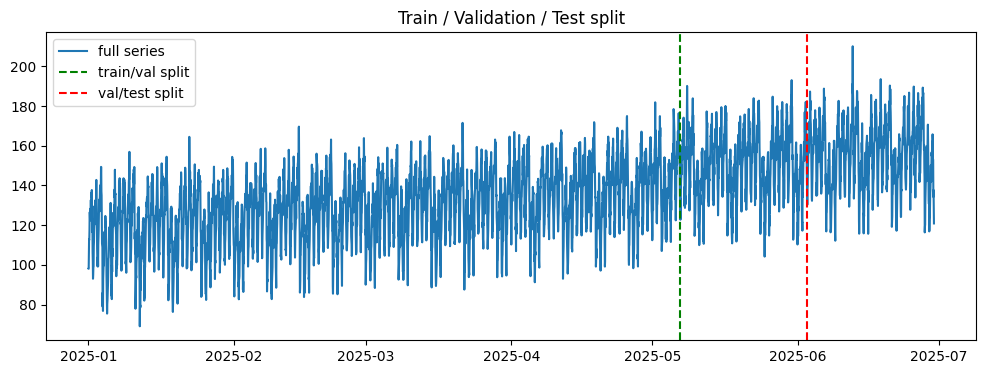

In [180]:
plt.figure(figsize=(12,4))
plt.plot(df['date'], df['target'], label='full series')
plt.axvline(df['date'].iloc[train_end], color='g', linestyle='--', label='train/val split')
plt.axvline(df['date'].iloc[val_end], color='r', linestyle='--', label='val/test split')
plt.legend()
plt.title("Train / Validation / Test split")
plt.savefig("artifacts/figures/series_split.png")
plt.show()

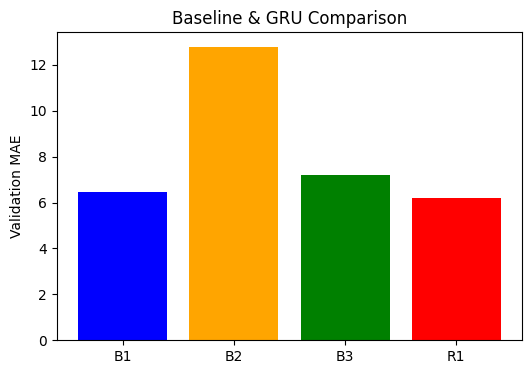

In [181]:
metrics = [b1_val_mae, b2_val_mae, b3_val_mae, r1_val_mae]
labels = ["B1", "B2", "B3", "R1"]

plt.figure(figsize=(6,4))
plt.bar(labels, metrics, color=['blue','orange','green','red'])
plt.ylabel("Validation MAE")
plt.title("Baseline & GRU Comparison")
plt.savefig("artifacts/figures/baselines_compare.png")
plt.show()

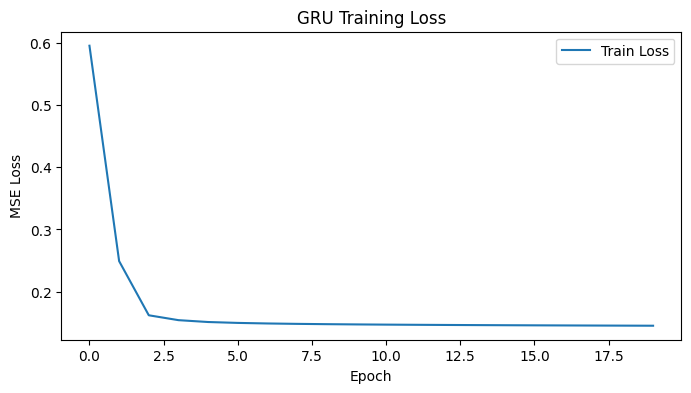

In [182]:
plt.figure(figsize=(8,4))
plt.plot(train_losses, label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("GRU Training Loss")
plt.legend()
plt.savefig("artifacts/figures/gru_learning_curves.png")
plt.show()

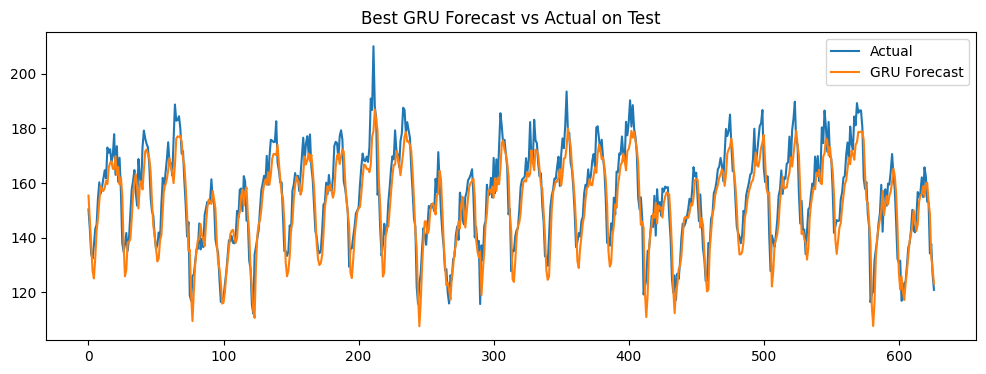

In [183]:
plt.figure(figsize=(12,4))
plt.plot(targets, label='Actual')
plt.plot(best_preds, label='GRU Forecast')
plt.title("Best GRU Forecast vs Actual on Test")
plt.legend()
plt.savefig("artifacts/figures/best_forecast_test.png")
plt.show()